# Embedding Similarity Explorer
Embed a list of strings with `text-embedding-3-small`, then compare every pair by **cosine similarity** and **Euclidean distance**.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

In [2]:
# ── Strings to compare ───────────────────────────────────────────────────────
# Edit this list freely — add, remove, or change any strings.
strings = [
    "The contract shall be governed by the laws of Ireland.",
    "This agreement is subject to Irish law.",
    "The weather in Dublin is often cloudy.",
    "All disputes shall be resolved under Irish jurisdiction.",
    "It tends to rain a lot in Ireland.",
    "The parties agree to submit to the exclusive jurisdiction of the Irish courts.",
]

In [3]:
# ── Embed ─────────────────────────────────────────────────────────────────────
MODEL = "text-embedding-3-small"

response = client.embeddings.create(input=strings, model=MODEL)
embeddings = np.array([item.embedding for item in response.data])

print(f"Embedded {len(strings)} strings → shape {embeddings.shape}")

Embedded 6 strings → shape (6, 1536)


In [4]:
# ── Similarity / distance matrices ───────────────────────────────────────────
def cosine_similarity_matrix(vecs: np.ndarray) -> np.ndarray:
    """Pairwise cosine similarity.  Range: [-1, 1], higher = more similar."""
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    normed = vecs / np.where(norms == 0, 1, norms)
    return normed @ normed.T

def euclidean_distance_matrix(vecs: np.ndarray) -> np.ndarray:
    """Pairwise Euclidean distance.  Range: [0, ∞), lower = more similar."""
    diff = vecs[:, None, :] - vecs[None, :, :]      # (n, n, d)
    return np.sqrt((diff ** 2).sum(axis=-1))

cos_sim  = cosine_similarity_matrix(embeddings)
euc_dist = euclidean_distance_matrix(embeddings)

# Short labels for readability
labels = [f"S{i+1}" for i in range(len(strings))]
print("Labels:")
for label, s in zip(labels, strings):
    print(f"  {label}: {s}")

Labels:
  S1: The contract shall be governed by the laws of Ireland.
  S2: This agreement is subject to Irish law.
  S3: The weather in Dublin is often cloudy.
  S4: All disputes shall be resolved under Irish jurisdiction.
  S5: It tends to rain a lot in Ireland.
  S6: The parties agree to submit to the exclusive jurisdiction of the Irish courts.


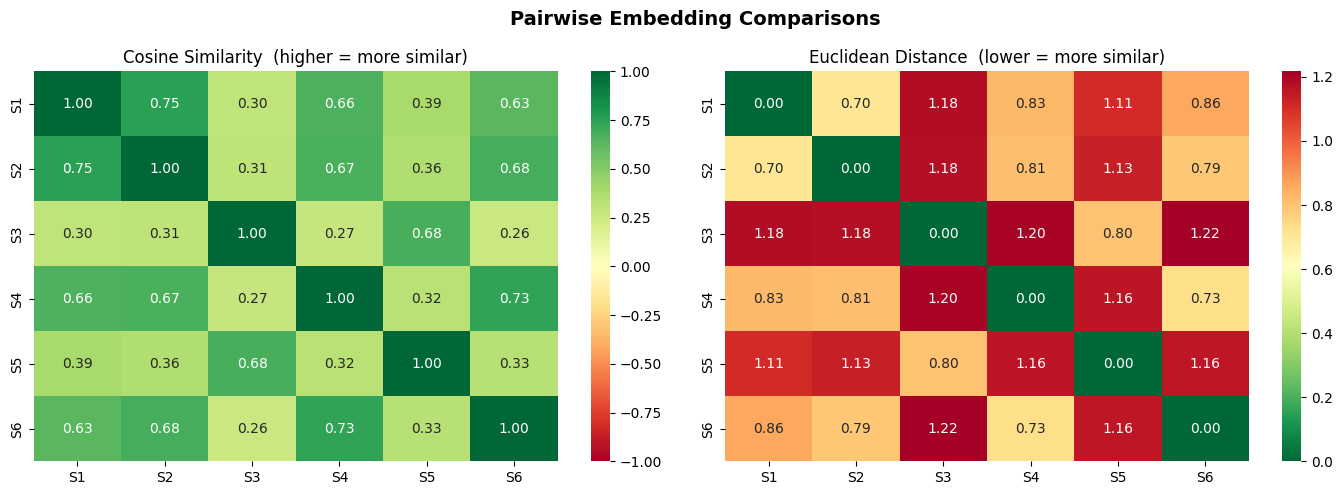

In [5]:
# ── Heatmaps ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pairwise Embedding Comparisons", fontsize=14, fontweight="bold")

sns.heatmap(
    cos_sim,
    annot=True, fmt=".2f", cmap="RdYlGn",
    xticklabels=labels, yticklabels=labels,
    vmin=-1, vmax=1,
    ax=axes[0],
)
axes[0].set_title("Cosine Similarity  (higher = more similar)")

sns.heatmap(
    euc_dist,
    annot=True, fmt=".2f", cmap="RdYlGn_r",
    xticklabels=labels, yticklabels=labels,
    ax=axes[1],
)
axes[1].set_title("Euclidean Distance  (lower = more similar)")

plt.tight_layout()
plt.show()

In [6]:
# ── Ranked pairs table ────────────────────────────────────────────────────────
n = len(strings)
rows = []
for i in range(n):
    for j in range(i + 1, n):
        rows.append({
            "Pair": f"{labels[i]} vs {labels[j]}",
            "String A": strings[i][:60] + ("..." if len(strings[i]) > 60 else ""),
            "String B": strings[j][:60] + ("..." if len(strings[j]) > 60 else ""),
            "Cosine Similarity": round(float(cos_sim[i, j]), 4),
            "Euclidean Distance": round(float(euc_dist[i, j]), 4),
        })

df = (
    pd.DataFrame(rows)
    .sort_values("Cosine Similarity", ascending=False)
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", 65)
df

,Pair,String A,String B,Cosine Similarity,Euclidean Distance
0,S1 vs S2,The contract shall be governed by the laws of Ireland.,This agreement is subject to Irish law.,0.7522,0.7040
1,S4 vs S6,All disputes shall be resolved under Irish jurisdiction.,The parties agree to submit to the exclusive jurisdiction of...,0.7347,0.7286
2,S2 vs S6,This agreement is subject to Irish law.,The parties agree to submit to the exclusive jurisdiction of...,0.6849,0.7937
3,S3 vs S5,The weather in Dublin is often cloudy.,It tends to rain a lot in Ireland.,0.6782,0.8021
4,S2 vs S4,This agreement is subject to Irish law.,All disputes shall be resolved under Irish jurisdiction.,0.6702,0.8121
5,S1 vs S4,The contract shall be governed by the laws of Ireland.,All disputes shall be resolved under Irish jurisdiction.,0.6584,0.8268
6,S1 vs S6,The contract shall be governed by the laws of Ireland.,The parties agree to submit to the exclusive jurisdiction of...,0.6293,0.8611
7,S1 vs S5,The contract shall be governed by the laws of Ireland.,It tends to rain a lot in Ireland.,0.3865,1.1076
8,S2 vs S5,This agreement is subject to Irish law.,It tends to rain a lot in Ireland.,0.3562,1.1342
9,S5 vs S6,It tends to rain a lot in Ireland.,The parties agree to submit to the exclusive jurisdiction of...,0.3308,1.1566


In [7]:
# ── Threshold filter ──────────────────────────────────────────────────────────
# Show only pairs whose cosine similarity exceeds this threshold.
# Polydoc uses 0.3 cosine *distance* = 0.7 cosine similarity as its cache-hit threshold.
COSINE_THRESHOLD = 0.70

hits = df[df["Cosine Similarity"] >= COSINE_THRESHOLD]
print(f"Pairs above cosine similarity {COSINE_THRESHOLD} (cache hits in Polydoc):")
hits[["Pair", "Cosine Similarity", "String A", "String B"]]

Pairs above cosine similarity 0.7 (cache hits in Polydoc):


,Pair,Cosine Similarity,String A,String B
0,S1 vs S2,0.7522,The contract shall be governed by the laws of Ireland.,This agreement is subject to Irish law.
1,S4 vs S6,0.7347,All disputes shall be resolved under Irish jurisdiction.,The parties agree to submit to the exclusive jurisdiction of...
